## Laptop Fiyat Analizi - EDA PROJESİ

Veri setimiz 1303 adet veri içeriyor. Amacımız burada bağımlı değişken olan fiyat değişkenin diğer girdiler ile nasıl bir ilişkiye sahip olduğunu ortaya çıkarmak.

Eğer ki başarılı bir EDA işlemi gerçekleştirirsek ileride makine öğrenmesine uygun bir model, satıcı ve müşteriler için gerekli bilgiler elde edilir.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("laptop_price.csv", encoding="latin1")

## Meet With Data Set

In [9]:
data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


Veriyi tanıyarak sürece başladım. Kategorik ve sayısal verileri inceledim.

In [12]:
data.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


Burada genel bilgi topladım. Kaç adet veri var ? Minimum ve maksimum değerleri kontrol ettim.

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


Burada boş veri olmadığını öğrendim. Bu işimi kolaylaştırdı. Çünkü eksik veri yok.

In [18]:
data["Price_euros"].value_counts()

Price_euros
1499.0    14
1099.0    14
1799.0    14
899.0     11
1199.0    11
          ..
2090.0     1
304.0      1
759.0      1
1858.0     1
2699.0     1
Name: count, Length: 791, dtype: int64

Fiyatların dağılımına göz gezdirdim.

## Data Cleaning && Correlation Analysis

In [21]:
data["Ram"] = data["Ram"].str.replace("GB", "").astype(int)

Elimdeki girdilerin bağımlı değişkene(fiyat) etkisini incelemem için korelasyona ihtiyacım var. Fakat korelasyon sayısal bir değer olmak zorunda. Bunun için replace işlemi uyguladım.

In [24]:
data["Ram"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1303 entries, 0 to 1302
Series name: Ram
Non-Null Count  Dtype
--------------  -----
1303 non-null   int32
dtypes: int32(1)
memory usage: 5.2 KB


Eksik veri olmadığını bildiğimden ram sütununu tekrar kontrol ediyorum. Kayıp var mı kontrol ediyorum

In [27]:
data[["Ram","Price_euros"]].corr()

,Ram,Price_euros
Ram,1.000000,0.743007
Price_euros,0.743007,1.000000


Artık korelasyon yapacak duruma geldi. Ram'in fiyat üzerindeki etkisini gördüm.

<Axes: xlabel='Ram', ylabel='Price_euros'>

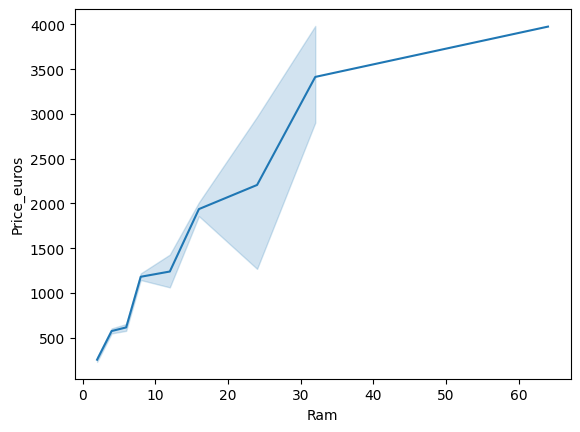

In [30]:
sns.lineplot(x="Ram",y="Price_euros",data=data)

In [31]:
data["CPU_brand"] = data["Cpu"].str.split().str[0]

Burası "Ram"'e göre biraz daha zorlu bir kısım. Çünkü "Ram"'de sadece replace işlemi yaptım. Burada replace yapamam çünkü işlemcinin markası, Ghz değeri ve serisi fiyatı etkiler.

İlk olarak marka kısmını ayırdım. Split fonksiyonu ile ilk boşluktan ayırma işlemi yaptım.

In [34]:
data["CPU_series"] = data["Cpu"].str.extract("(i\\d)")
mapping = {"i3": 3, "i5": 5, "i7": 7, "i9": 9}
data["CPU_series"] = data["CPU_series"].map(mapping)

Burada ise seri kısmını yakalamam gerekiyordu. 'i''den devam eden kısımları yakaladım.

Bir sözlük oluşturdum. Serilere karşılık gelen değerleri tanımladım. Daha sonrasında map işlemi ile eşleştirdim.

In [40]:
data["CPU_GHz"] = data["Cpu"].str.extract("(\\d+\\.?\\d*)\\s*GHz").astype(float)

Burada ise Ghz yakalamak için sonunda mutlaka Ghz olması gerektiğini şartladım. Diğer olasılıkları parantez içine koydum. Örneğin 2.4 Ghz için . olabilir için \.? kullandım.

In [43]:
data[["Cpu", "CPU_brand", "CPU_series", "CPU_GHz"]].head(5)

,Cpu,CPU_brand,CPU_series,CPU_GHz
0,Intel Core i5 2.3GHz,Intel,5.0,2.3
1,Intel Core i5 1.8GHz,Intel,5.0,1.8
2,Intel Core i5 7200U 2.5GHz,Intel,5.0,2.5
3,Intel Core i7 2.7GHz,Intel,7.0,2.7
4,Intel Core i5 3.1GHz,Intel,5.0,3.1


Daha sonra Cpu ayırma işlemini kontrol ettim. Doğru bir ayrım olmuş

In [46]:
data[["CPU_series", "CPU_GHz", "Price_euros"]].corr()

,CPU_series,CPU_GHz,Price_euros
CPU_series,1.000000,0.394818,0.567748
CPU_GHz,0.394818,1.000000,0.430293
Price_euros,0.567748,0.430293,1.000000


Korelasyon ile fiyatı nasıl etkilediğini kontrol ettim

In [49]:
data["Memory"] = data["Memory"].str.extract("(\\d+)").astype(int)

Hafıza kısmında başlangıçta "Ram" sütununa uyguladıgımız gibi replace yapmak istedim. Fakat birden fazla tür olduğu için sıkıntı yaşadım. Örneğin SSD, TB, HDD gibi. Bunun yerine sayının bittiği yerden yakalama işlemi uyguladım

In [52]:
data[["Memory","Price_euros"]].corr()

,Memory,Price_euros
Memory,1.000000,0.298177
Price_euros,0.298177,1.000000


Daha sonra korelasyon ile hafızanın fiyatı nasıl etkilediğini inceledim.

In [55]:
data["Ram"].value_counts()

Ram
8     619
4     375
16    200
6      41
12     25
2      22
32     17
24      3
64      1
Name: count, dtype: int64

<Axes: xlabel='Ram', ylabel='Price'>

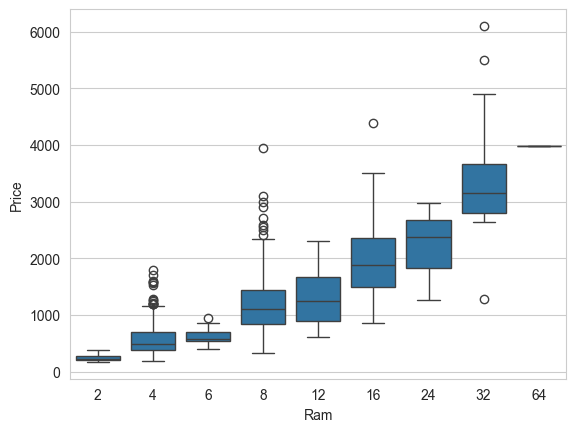

In [57]:
sns.set_style("whitegrid")
plt.xlabel("Ram")
plt.ylabel("Price")
sns.boxplot(x="Ram",y="Price_euros",data=data)

Seaborn ile ram ve fiyat arasındaki ilişkiyi boxplot üzerinde incelemek istedim. Outlierlar var. Bunlar başlangıçta o ram değerini satın alanların fazla para ödediğini düşündürüyor. Fakat fiyat üzerindeki tek etkenimiz Ram değil bunu göz önünde bulundurmamız gerekiyor.

<Axes: xlabel='Ram', ylabel='Price_euros'>

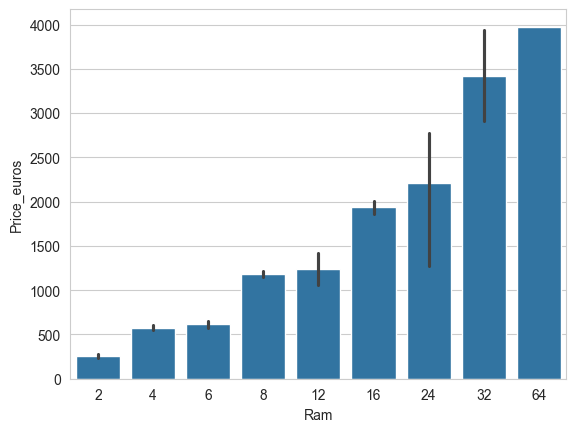

In [59]:
sns.barplot(x="Ram",y="Price_euros",data=data)

In [64]:
data["Ram"].describe()

count    1303.000000
mean        8.382195
std         5.084665
min         2.000000
25%         4.000000
50%         8.000000
75%         8.000000
max        64.000000
Name: Ram, dtype: float64

In [70]:
data["Weight"] = data["Weight"].str.replace("kg","")

Ram sütununda yaptığımız islemin aynısını burada yaptım.

In [72]:
data[["Weight","Price_euros"]].corr()

,Weight,Price_euros
Weight,1.00000,0.21037
Price_euros,0.21037,1.00000


Korelasyon ile fiyat arasındaki bağıntısını gördüm.

In [74]:
data[["Inches","Price_euros"]].corr()

,Inches,Price_euros
Inches,1.000000,0.068197
Price_euros,0.068197,1.000000


Ekran Inch değeri ile fiyat arasında korelasyon yaptım

In [82]:
data.groupby("Company").mean(numeric_only=True)

,laptop_ID,Inches,Ram,Memory,Price_euros,CPU_series,CPU_GHz
Company,,,,,,,
Acer,585.087379,15.063107,5.980583,166.485437,626.775825,4.910448,2.117476
Apple,304.142857,13.247619,9.333333,323.047619,1564.198571,5.500000,1.990476
Asus,614.765823,15.450000,9.594937,206.550633,1104.169367,6.185841,2.267975
Chuwi,316.333333,14.500000,4.666667,64.000000,314.296667,NaN,1.326667
Dell,650.599327,15.136027,9.151515,221.659933,1186.068990,5.652482,2.279798
Fujitsu,733.666667,15.600000,6.666667,171.000000,729.000000,5.000000,2.433333
Google,564.666667,12.300000,10.666667,298.666667,1677.666667,5.666667,1.233333
HP,703.722628,14.943066,6.912409,244.624088,1067.774854,5.571429,2.307299
Huawei,196.500000,13.000000,8.000000,384.000000,1424.000000,6.000000,2.600000


Markalar 'String' türde olduğu için korelasyon yapamadım sadece gruplama işlemi yaparak ortalama fiyatları kontrol ettim.

In [94]:
data.groupby("Company").max()

,laptop_ID,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,CPU_brand,CPU_series,CPU_GHz
Company,,,,,,,,,,,,,,,
Acer,1309,TravelMate P259-G2,Ultrabook,17.3,IPS Panel Touchscreen 1366x768,Intel Pentium Quad Core N4200 1.1GHz,16,500,Nvidia GeForce MX150,Windows 10,4.2,2599.00,Intel,7.0,3.00
Apple,1252,Macbook Air,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512,Intel Iris Pro Graphics,macOS,2.04,2858.00,Intel,7.0,3.10
Asus,1320,Zenbook UX510UW-FI095T,Ultrabook,17.3,Touchscreen 1366x768,Intel Pentium Quad Core N4200 1.1GHz,64,512,Nvidia GeForce MX150,Windows 10 S,4.7,3975.00,Intel,7.0,3.20
Chuwi,490,"Lapbook 15,6",Notebook,15.6,IPS Panel Retina Display 2736x1824,Intel Celeron Quad Core N3450 1.1GHz,6,64,Intel HD Graphics 500,Windows 10,1.89,449.00,Intel,NaN,1.44
Dell,1313,XPS 15,Workstation,17.3,Touchscreen 2560x1440,Intel Xeon E3-1505M V6 3GHz,32,512,Nvidia Quadro M620,Windows 7,4.42,3659.40,Intel,7.0,3.00
Fujitsu,997,Lifebook A557,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8,256,Intel HD Graphics 620,Windows 10,2.3,799.00,Intel,5.0,2.50
Google,771,Pixelbook (Core,Ultrabook,12.3,Touchscreen 2400x1600,Intel Core i7 7Y75 1.3GHz,16,512,Intel HD Graphics 615,Chrome OS,1.1,2199.00,Intel,7.0,1.30
HP,1319,Zbook 17,Workstation,17.3,Touchscreen 2560x1440,Intel Xeon E3-1535M v5 2.9GHz,16,512,Nvidia Quadro M3000M,Windows 7,3.78,4389.00,Intel,7.0,3.00
Huawei,219,MateBook X,Ultrabook,13.0,IPS Panel Full HD 2160x1440,Intel Core i7 7500U 2.7GHz,8,512,Intel HD Graphics 620,Windows 10,1.05,1499.00,Intel,7.0,2.70


Markaların maksimum fiyat değerlerini kontrol ettim.

In [88]:
data.groupby("Gpu").mean(numeric_only = True)

,laptop_ID,Inches,Ram,Memory,Price_euros,CPU_series,CPU_GHz
Gpu,,,,,,,
AMD FirePro W4190M,1101.0,15.6,8.0,256.0,1495.00,7.0,2.50
AMD FirePro W4190M,356.0,15.6,8.0,250.5,1211.50,6.0,2.60
AMD FirePro W5130M,393.0,15.6,8.0,500.0,1369.00,5.0,2.60
AMD FirePro W6150M,1118.0,17.3,8.0,1.0,2899.00,7.0,2.60
AMD R17M-M1-70,182.0,15.6,8.0,128.0,813.00,5.0,2.50
...,...,...,...,...,...,...,...
Nvidia Quadro M3000M,1151.0,17.3,8.0,256.0,3949.40,7.0,2.60
Nvidia Quadro M500M,1146.0,14.0,8.0,512.0,2050.38,7.0,2.60
Nvidia Quadro M520M,733.5,15.6,16.0,256.5,2577.00,7.0,2.65


Laptop fiyatlandırmasında belki de en önemli girdi ekran kartıdır. Fakat diğer girdiler gibi ekran kartına herhangi bir işlem yapamadım. Yani korelasyonuna bakamadım. Bu yüzden ortalama değer kontrol ettim.

## ÖZET

Girdiler genel olarak incelendi.Temizlenmesi gereken veriler temizlendi. Korelasyona uygun hale getirildi. Korelasyona uygun hale getirilemeyen veriler için gruplandırma işlemi ile ortalama değerler kontrol edildi.

## GENEL ÇIKARIM

Sonuçları incelediğimizde girdilerin fiyat üzerinde pozitif etkisinin olduğu bulundu. Beklenenin aksine 'Weight' bağımsız değişkeni fiyat üzerinde 0.21'lik korelasyon değeri ile pozitif etkiye sahip çıktı.

Yapılacak bir modellemede 'Ram' değişkeninin katsayısının diğerlerine nazaran daha büyük olması beklenir. Çünkü korelasyon oranı en yüksek olan değişken.

'Weight' bağımsız değişken